# Graph 1: Genre Over Time

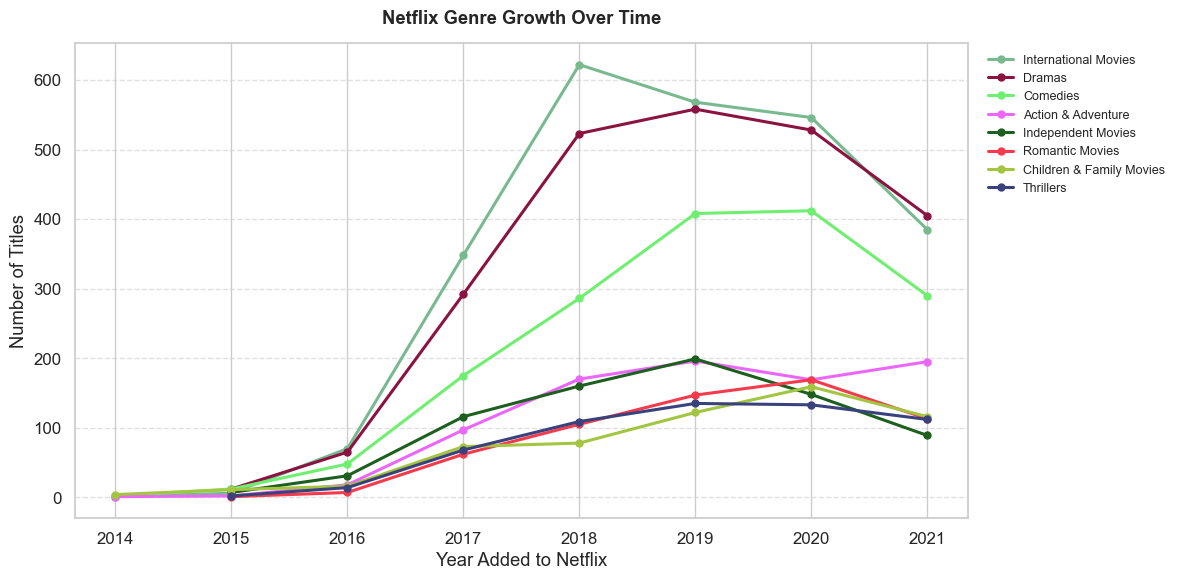

Saved → graph1_genre_over_time.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from genre_colors import GENRE_COLORS

df = pd.read_csv("netflix_titles_clean.csv")
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

# Explode listed_in into one genre per row
df["genre"] = df["listed_in"].str.split(", ")
exploded = df.explode("genre")
exploded["genre"] = exploded["genre"].str.strip()

# top 8 genres by total count
top_genres = (
    exploded["genre"]
    .value_counts()
    .head(8)
    .index
    .tolist()
)

# full year range present in the data
year_min = 2014
year_max = int(df["year_added"].max())

data = (
    exploded[
        exploded["genre"].isin(top_genres) &
        exploded["year_added"].between(year_min, year_max)
    ]
    .groupby(["year_added", "genre"])
    .size()
    .reset_index(name="count")
)

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(12, 6))

for i, genre in enumerate(top_genres):
    subset = data[data["genre"] == genre]
    ax.plot(
        subset["year_added"], subset["count"],
        marker="o", linewidth=2.2, markersize=5,
        color=GENRE_COLORS.get(genre, "#888888"), label=genre,
    )

ax.set_title(
    f"Netflix Genre Growth Over Time", fontweight="bold", pad=14
)
ax.set_xlabel("Year Added to Netflix")
ax.set_ylabel("Number of Titles")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9, frameon=False)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("graph1_genre_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved \u2192 graph1_genre_over_time.png")
